In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\sheet\Downloads\agriculture_yield_dataset.csv")

# Number of rows and columns
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# First 10 records
print("\nFirst 10 Records:")
print(df.head(10))

Shape: (1500, 8)

Columns:
Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')

First 10 Records:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4       

In [4]:
# Data types
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Columns with missing values
print("\nColumns having missing values:")
print(df.columns[df.isnull().any()])

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

Columns having missing values:
Index([], dtype='object')


In [5]:
summary = df.describe()

print(summary)

# Highest mean
print("\nFeature with Highest Mean:")
print(summary.loc["mean"].idxmax())

# Highest Standard Deviation
print("\nFeature with Highest Std:")
print(summary.loc["std"].idxmax())

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

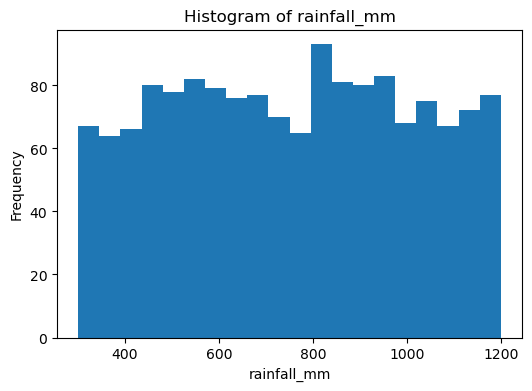

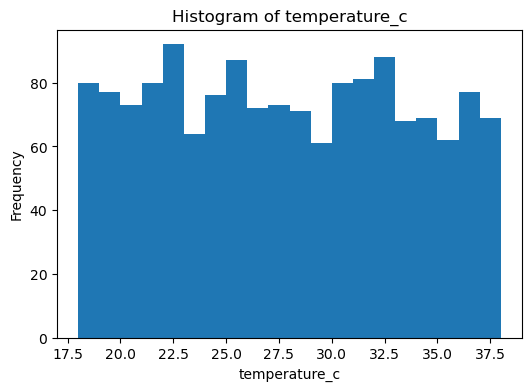

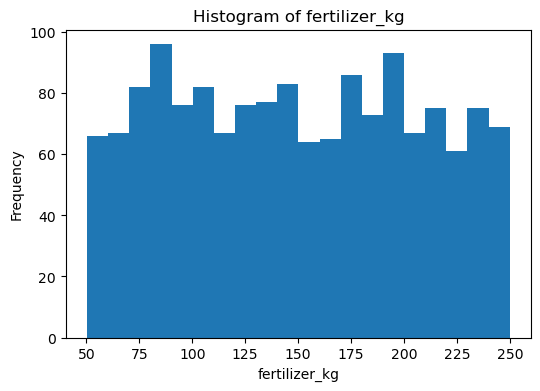

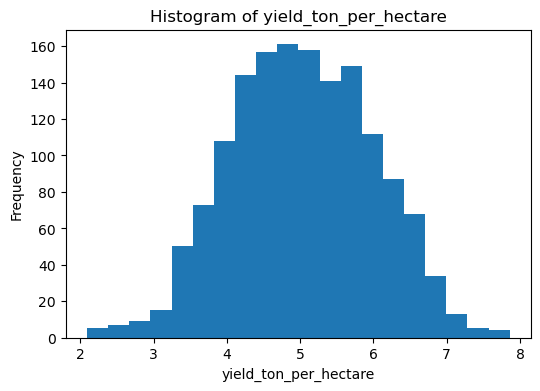

In [6]:
import matplotlib.pyplot as plt

columns = [
    "rainfall_mm",
    "temperature_c",
    "fertilizer_kg",
    "yield_ton_per_hectare"
]

for col in columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


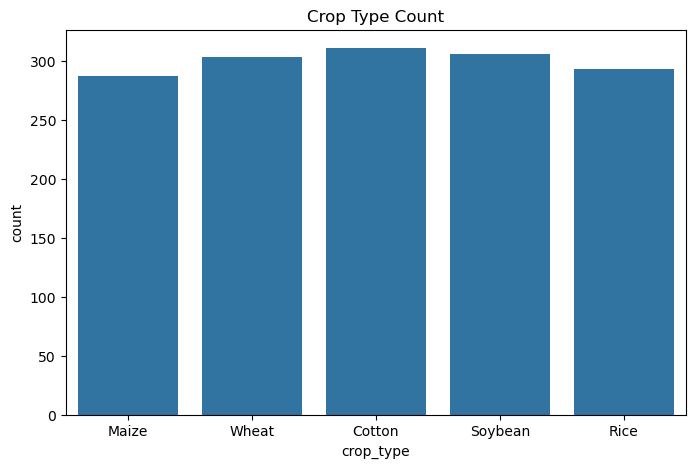

Most Frequent Crop:
Cotton


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

print(df["crop_type"].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(x="crop_type", data=df)
plt.title("Crop Type Count")
plt.show()

print("Most Frequent Crop:")
print(df["crop_type"].mode()[0])

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


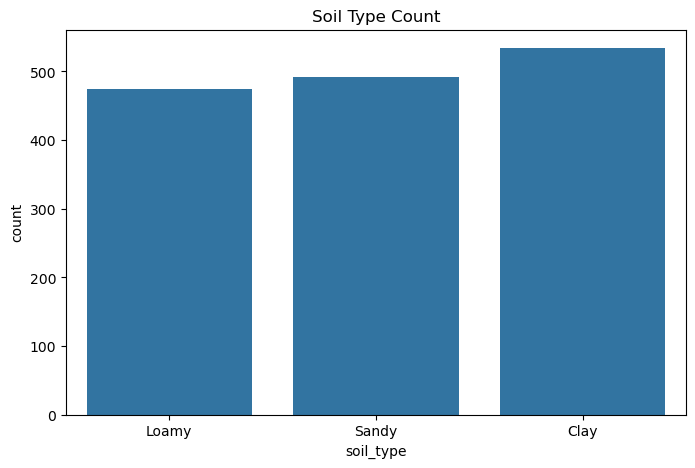

Most Common Soil Type:
Clay


In [8]:
print(df["soil_type"].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(x="soil_type", data=df)
plt.title("Soil Type Count")
plt.show()

print("Most Common Soil Type:")
print(df["soil_type"].mode()[0])

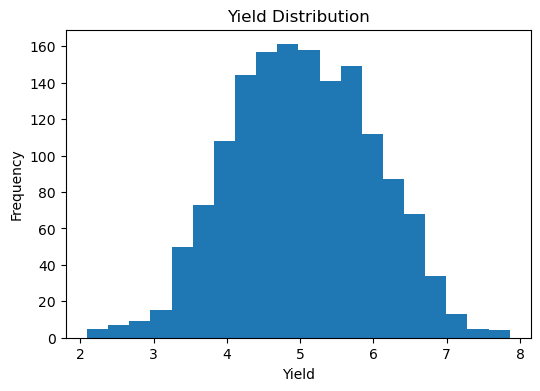

In [9]:
plt.figure(figsize=(6,4))
plt.hist(df["yield_ton_per_hectare"], bins=20)
plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

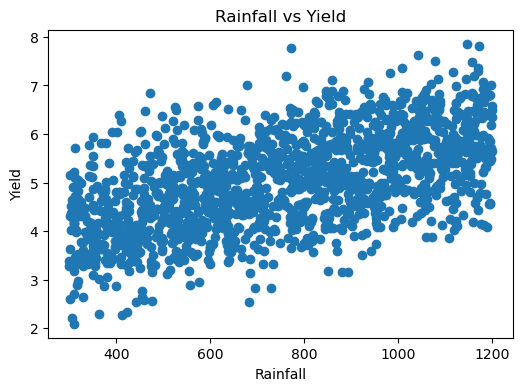

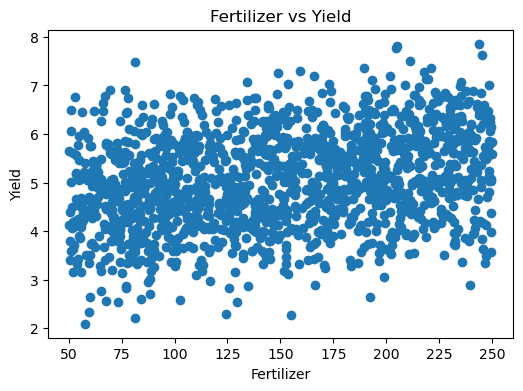

In [10]:
plt.figure(figsize=(6,4))
plt.scatter(df["rainfall_mm"], df["yield_ton_per_hectare"])
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.title("Rainfall vs Yield")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df["fertilizer_kg"], df["yield_ton_per_hectare"])
plt.xlabel("Fertilizer")
plt.ylabel("Yield")
plt.title("Fertilizer vs Yield")
plt.show()

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

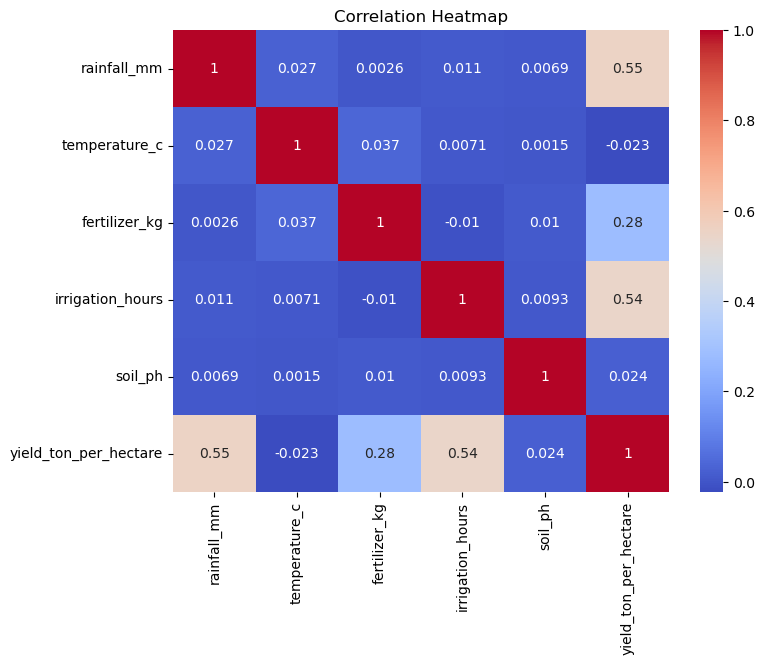


Top Correlated Features:
yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64


In [11]:
import seaborn as sns

numeric_df = df.select_dtypes(include=["int64", "float64"])

corr_matrix = numeric_df.corr()

print(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Top 3 correlated with yield
corr_yield = corr_matrix["yield_ton_per_hectare"].sort_values(ascending=False)

print("\nTop Correlated Features:")
print(corr_yield)

In [12]:
crop_yield = df.groupby("crop_type")["yield_ton_per_hectare"].mean()
print("\nAverage Yield by Crop:")
print(crop_yield)

soil_yield = df.groupby("soil_type")["yield_ton_per_hectare"].mean()
print("\nAverage Yield by Soil:")
print(soil_yield)

print("\nHighest Yield Crop:")
print(crop_yield.idxmax())

print("\nHighest Yield Soil:")
print(soil_yield.idxmax())


Average Yield by Crop:
crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Average Yield by Soil:
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Highest Yield Crop:
Rice

Highest Yield Soil:
Loamy


In [13]:
encoded_df = pd.get_dummies(df, columns=["crop_type", "soil_type"])

print(encoded_df.head())

   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Cotton  crop_type_Maize  crop_type_Rice  \
0                   5.92             False             True           False   
1                   6.24             False             True           False   
2                   4.77             False            False           False   
3                   4.04             False             True           False   
4                   5.17              True            False           False   

   crop_type_Soybean  crop_type_Wheat  soil_type_Clay  soil_type_Loamy  \


In [14]:
X = encoded_df.drop("yield_ton_per_hectare", axis=1)

y = encoded_df["yield_ton_per_hectare"]

print("Input Features (X):")
print(X.head())

print("\nTarget Variable (y):")
print(y.head())

Input Features (X):
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   crop_type_Cotton  crop_type_Maize  crop_type_Rice  crop_type_Soybean  \
0             False             True           False              False   
1             False             True           False              False   
2             False            False           False              False   
3             False             True           False              False   
4              True            False           False              False   

   crop_type_Wheat  soil_type_Clay  soil_type_Loamy  soil_type_Sandy  
0      

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)